# Master timeline — 18 January 2026 X1.9 event

One shared time axis, stacked top to bottom:

1. **Solar Orbiter/STIX** hard X-rays — 4–10 / 10–15 / 15–25 / 25–50 / 50–84 keV
2. **GOES/XRS** soft X-rays — 0.5–4 Å and 1–8 Å
3. **EOVSA** microwave total power (frequency-integrated)
4. **OVRO-LWA** decametric–metric dynamic spectrum (15–85 MHz)
5. Interplanetary dynamic spectrum — **Wind/WAVES** (RAD1+RAD2) or **Solar Orbiter/RPW** (HFR[+TNR]), toggle `IP_SOURCE`

Markers on every panel: QPP interval (`axvspan`), Type II onset and CME first C2 appearance (`axvline`).

Everything is on the **Earth-arrival** time frame. STIX (and RPW, if selected) sit at Solar Orbiter,
closer to the Sun than Earth, so their photons arrive early; both are shifted by
$+\Delta t_{\rm LT}=(d_\oplus-d_{\rm SolO})\times499.005\,\mathrm{s\,au^{-1}}$ (~119 s here). Wind, GOES,
EOVSA and OVRO-LWA are already Earth/L1 and left untouched.

STIX, GOES, EOVSA and OVRO-LWA read the local event files under `DATA_ROOT/2026-01-18/`. The
interplanetary panel downloads on first run (CDAWeb for Wind, SOAR for RPW) and caches under
`DATA_ROOT/2026-01-18/IP/`.

In [20]:
import warnings
warnings.filterwarnings('ignore')
import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from astropy.io import fits
from astropy.time import Time
import astropy.units as u

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

In [21]:
# ============================ configuration ============================
EVENT_DATE = '2026-01-18'
YMD = EVENT_DATE.replace('-', '')

# shared display axis
T_AXIS = (pd.Timestamp('2026-01-18T17:00:00'), pd.Timestamp('2026-01-18T20:00:00'))

# --- markers ---
# QPP interval -> axvspan (STIX non-thermal pulsation episode, 17:40-18:15 UT)
QPP_START = pd.Timestamp('2026-01-18T17:40:00')
QPP_END = pd.Timestamp('2026-01-18T18:15:00')
# Type II onset -> axvline (OVRO-LWA metric type II first appears ~17:55-17:56 UT)
TYPEII_ONSET = pd.Timestamp('2026-01-18T17:55:00')
# CME first appearance in SOHO/LASCO C2 -> axvline. 18:12 UT from the SIDC flare-catalogue
# entry for the X1.9 (SIDC Flare 6678); IRAP and The Watchers corroborate the surrounding
# timings (peak 18:09, type IV 18:13, L1 shock 19:03). Replace with the LASCO CME-catalogue
# first-C2 time if it differs.
CME_C2_FIRST = pd.Timestamp('2026-01-18T18:12:00')

# interplanetary panel source: 'wind' (L1, Earth frame) or 'rpw' (Solar Orbiter frame)
IP_SOURCE = 'wind'
IP_FREQ_MHZ_LIM = (0.02, 16.0)      # display band for the IP panel [MHz]
IP_BIN_S = 60                        # IP spectrogram time grid [s] (Wind/WAVES cadence ~60 s)

# quiet pre-flare baseline for per-channel radio background
RADIO_BKG = (pd.Timestamp('2026-01-18T16:30:00'), pd.Timestamp('2026-01-18T17:20:00'))

# display cadence for the OVRO-LWA spectrogram (time-average to this many seconds)
SPEC_BIN_S = 3

# Earth-arrival light-travel shift for Solar Orbiter series (recomputed below; fallback if
# Horizons is unreachable)
LT_SHIFT_S_FALLBACK = 119.4

# --- data location: pick the first root that actually holds the event tree ---
# On the DIAS machine the data live under /home/mnedal/data; '.' covers a local copy.
DATA_ROOT_CANDIDATES = ['/home/mnedal/data', '.', os.path.expanduser('~/data')]
data_dir = next((d for d in DATA_ROOT_CANDIDATES if os.path.isdir(f'{d}/{EVENT_DATE}/STIX')),
                DATA_ROOT_CANDIDATES[0])
event_dir = f'{data_dir}/{EVENT_DATE}'
fig_dir = f'{event_dir}/figures'
paths = {
    'stix': f'{event_dir}/STIX',
    'goes': f'{event_dir}/XRS',
    'eovsa': f'{event_dir}/EOVSA',
    'lwa': f'{event_dir}/LWA',
    'ip': f'{event_dir}/IP',
}
for p in [fig_dir, paths['ip']]:
    os.makedirs(p, exist_ok=True)
print(f'DATA_ROOT = {data_dir}   (event tree: {event_dir})')

STIX_BANDS = ['4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV']
STIX_COLORS = ['tab:blue', 'tab:cyan', 'tab:green', 'tab:orange', 'tab:red']

DATA_ROOT = /home/mnedal/data   (event tree: /home/mnedal/data/2026-01-18)


In [22]:
# ============================ helpers ============================
def savefig(fig, name):
    fig.savefig(f'{fig_dir}/{name}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/{name}.png', dpi=300, bbox_inches='tight')
    print(f'saved {fig_dir}/{name}.pdf|png')


def earth_arrival_shift_s(t_ref):
    """Seconds to add to a Sun-Solar-Orbiter signal to align it with Sun-Earth arrival."""
    try:
        from sunpy.coordinates import get_horizons_coord, get_earth
        d_solo = float(get_horizons_coord('Solar Orbiter', t_ref).radius.to_value(u.au))
        d_earth = float(get_earth(t_ref).radius.to_value(u.au))
        return 499.005 * (d_earth - d_solo)
    except Exception as exc:
        print(f'  Horizons unavailable ({exc}); using fallback {LT_SHIFT_S_FALLBACK} s')
        return LT_SHIFT_S_FALLBACK


def bin_spectrogram_time(t_index, spec, bin_s):
    """Average a (nfreq, ntime) spectrogram onto a uniform bin_s grid -> (t_grid, spec_binned)."""
    t = pd.DatetimeIndex(t_index)
    t0 = t[0]
    sec = (t - t0).total_seconds().values
    edges = np.arange(0, sec[-1] + bin_s, bin_s)
    idx = np.clip(np.digitize(sec, edges) - 1, 0, len(edges) - 2)
    binned = pd.DataFrame(spec.T).groupby(idx).mean()             # (nbin_present, nfreq), C-level
    t_grid = pd.DatetimeIndex(t0 + pd.to_timedelta(edges[binned.index.values] + bin_s / 2, unit='s'))
    return t_grid, binned.values.T


def bkg_divide(spec, t_index, bkg_window):
    """Per-channel background division over bkg_window (falls back to the first 5% of the record)."""
    bsel = (t_index >= bkg_window[0]) & (t_index <= bkg_window[1])
    if bsel.sum() < 5:
        bsel = np.zeros(len(t_index), dtype=bool)
        bsel[:max(5, int(0.05 * len(t_index)))] = True
    bkg = np.nanmedian(spec[:, bsel].astype(float), axis=1)[:, None]
    with np.errstate(all='ignore'):
        return spec.astype(float) / bkg


def window_pad(lo, hi, minutes=5):
    return lo - pd.Timedelta(minutes=minutes), hi + pd.Timedelta(minutes=minutes)

In [23]:
# ============================ STIX (5 bands, Earth-arrival) ============================
from stixpy.product import Product
from stixpy.net.client import STIXClient  # noqa: F401  registers the STIX Fido client


def clean_stix_band(t_index, rate_band, rcr, timedel, dt_s=4, guard_s=20):
    """
    Interpolate a STIX QL band onto a uniform dt_s grid, bridging attenuator-in stretches.
    During the flare peak the attenuator (RCR state) moves in and the soft channels drop
    sharply; those samples are masked (whole RCR!=baseline interval + a guard around every
    transition + over-long integrations) and interpolated across, so the light curve shows the
    trend rather than the attenuator notches.
    """
    t = pd.DatetimeIndex(t_index)
    rcr = np.asarray(rcr)
    base = np.bincount(rcr.astype(int)).argmax() if rcr.size else 0    # usual (no-attenuator) state
    bad = rcr != base
    for i in np.where(np.diff(rcr) != 0)[0]:                            # guard the transitions
        t_ch = t[i]
        bad |= (t >= t_ch - pd.Timedelta(seconds=guard_s)) & (t <= t_ch + pd.Timedelta(seconds=guard_s))
    bad |= timedel > 2 * np.median(timedel)
    if bad.all():
        bad = np.zeros(len(t), dtype=bool)                             # never mask everything
    grid = pd.date_range(t[0], t[-1], freq=f'{dt_s}s')
    rate_i = np.interp(mdates.date2num(grid), mdates.date2num(t[~bad]), rate_band[~bad])
    return grid, rate_i


ql_local = sorted(glob.glob(f"{paths['stix']}/solo_L1_stix-ql-lightcurve_{YMD}*.fits"))
if ql_local:
    ql_file = ql_local[0]
    print(f'STIX QL (local): {os.path.basename(ql_file)}')
else:
    from sunpy.net import Fido, attrs as a
    q = Fido.search(a.Time(T_AXIS[0].isoformat(), T_AXIS[1].isoformat()), a.Instrument('STIX'),
                    a.stix.DataType('ql'), a.stix.DataProduct.ql_lightcurve)
    ql_file = sorted(Fido.fetch(q, path=f"{paths['stix']}/{{file}}"))[0]
    print(f'STIX QL (downloaded): {os.path.basename(ql_file)}')

ql = Product(ql_file)
stix_time = pd.DatetimeIndex(ql.data['time'].datetime)
timedel = np.atleast_1d(ql.data['timedel'].to_value(u.s))
rate = np.asarray(ql.data['counts']) / timedel[:, None]                # counts -> counts/s
rcr = np.asarray(ql.data['rcr']) if 'rcr' in ql.data.colnames else np.zeros(len(stix_time))

LT_SHIFT_S = earth_arrival_shift_s(pd.Timestamp('2026-01-18T18:09:00'))
stix_time = stix_time + pd.Timedelta(seconds=LT_SHIFT_S)
print(f'STIX shifted +{LT_SHIFT_S:.1f} s to Earth-arrival frame')

keep = (stix_time >= window_pad(*T_AXIS, 10)[0]) & (stix_time <= window_pad(*T_AXIS, 10)[1])
stix_time, rate, rcr, timedel = stix_time[keep], rate[keep], rcr[keep], timedel[keep]

stix = {}
for j, band in enumerate(STIX_BANDS):
    grid, r_i = clean_stix_band(stix_time, rate[:, j], rcr, timedel)
    stix[band] = {'t': grid, 'rate': r_i}
print(f'STIX bands ready: {", ".join(STIX_BANDS)}')

STIX QL (local): solo_L1_stix-ql-lightcurve_20260118_V02.fits


2026-07-24 07:31:19 - sunpy - INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144)


INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
STIX shifted +119.4 s to Earth-arrival frame
STIX bands ready: 4-10 keV, 10-15 keV, 15-25 keV, 25-50 keV, 50-84 keV


In [24]:
# ============================ GOES/XRS soft X-rays ============================
def load_goes_xrs_nc(path):
    """GOES-R XRS L2 1-s netCDF -> DataFrame(xrsa, xrsb), quality-flagged, UTC index."""
    import netCDF4
    ds = netCDF4.Dataset(path)
    epoch = np.datetime64('2000-01-01T12:00:00')                            # file epoch
    idx = pd.DatetimeIndex(epoch + (np.asarray(ds.variables['time'][:]) * 1e9).astype('timedelta64[ns]'))
    out = {}
    for band in ['xrsa', 'xrsb']:
        flux = np.asarray(ds.variables[f'{band}_flux'][:], dtype=float)
        flag = np.asarray(ds.variables[f'{band}_flags'][:]) if f'{band}_flags' in ds.variables else np.zeros_like(flux)
        flux[flag != 0] = np.nan
        out[band] = flux
    ds.close()
    return pd.DataFrame(out, index=idx)


goes_local = sorted(glob.glob(f"{paths['goes']}/*xrsf-l2-flx1s*{YMD}*.nc"))
if goes_local:
    gdf = load_goes_xrs_nc(goes_local[0])
    print(f'GOES XRS (local): {os.path.basename(goes_local[0])}')
else:
    import sunpy.timeseries as ts
    from sunpy.net import Fido, attrs as a
    q = Fido.search(a.Time(T_AXIS[0].isoformat(), T_AXIS[1].isoformat()), a.Instrument('XRS'),
                    a.goes.SatelliteNumber(18), a.Resolution('flx1s'))
    gdf = ts.TimeSeries(Fido.fetch(q, path=f"{paths['goes']}/{{file}}"), concatenate=True).to_dataframe()
    print('GOES XRS (downloaded)')

lo, hi = window_pad(*T_AXIS, 10)
gdf = gdf.loc[lo:hi]

GOES XRS (local): sci_xrsf-l2-flx1s_g18_d20260118_v2-2-1.nc


In [25]:
# ============================ EOVSA microwave total power ============================
def load_eovsa_tpall(path):
    """EOVSA full-day total power: HDU0 (nfreq, ntime) SFU, SFREQ [GHz], UT (mjd, ms-of-day)."""
    with fits.open(path) as h:
        spec = np.asarray(h[0].data, dtype=float)
        fghz = np.asarray(h['SFREQ'].data['sfreq'], dtype=float).ravel()
        ut = h['UT'].data
        mjd = ut['mjd'] + ut['time'] / 86400000
    return pd.DatetimeIndex(Time(mjd, format='mjd').datetime), fghz, spec


def load_eovsa_spec_tp(path):
    """EOVSA flare-mode total power: HDU0 (nfreq, ntime) SFU, FGHZ [GHz], TIME [JD]."""
    with fits.open(path) as h:
        spec = np.asarray(h[0].data, dtype=float)
        fghz = np.asarray(h[1].data['fghz'], dtype=float).ravel()
        tjd = np.asarray(h[2].data['time'], dtype=float).ravel()
    return pd.DatetimeIndex(Time(tjd, format='jd').datetime), fghz, spec


eovsa_tpall = sorted(glob.glob(f"{paths['eovsa']}/EOVSA_TPall_*.fts"))
eovsa_flare = sorted(glob.glob(f"{paths['eovsa']}/eovsa*spec*tp*.fits"))
if eovsa_tpall:
    eov_t, eov_f, eov_s = load_eovsa_tpall(eovsa_tpall[0])
    print(f'EOVSA total power (full-day): {os.path.basename(eovsa_tpall[0])}')
elif eovsa_flare:
    eov_t, eov_f, eov_s = load_eovsa_spec_tp(eovsa_flare[0])
    print(f'EOVSA total power (flare mode): {os.path.basename(eovsa_flare[0])}')
else:
    eov_t = None
    print('EOVSA total-power file not found under', paths['eovsa'])

eov_tp = None
if eov_t is not None:
    lo, hi = window_pad(*T_AXIS, 10)
    eov_tp = pd.Series(np.nanmean(eov_s, axis=0), index=eov_t).loc[lo:hi]    # band-averaged SFU

EOVSA total power (full-day): EOVSA_TPall_20260118.fts


In [26]:
# ============================ OVRO-LWA dynamic spectrum ============================
def load_lwa_dyspec(path):
    """OVRO-LWA dynamic spectrum: primary (npol, 1, nfreq, ntime), SFREQ [GHz], UT (mjd, ms)."""
    with fits.open(path) as h:
        cube = h[0].data[:, 0, :, :]                        # (npol, nfreq, ntime)
        fmhz = np.asarray(h['SFREQ'].data['sfreq'], dtype=float) * 1e3
        ut = h['UT'].data
        mjd = ut['mjd'] + ut['time'] / 86400000
    return pd.DatetimeIndex(Time(mjd, format='mjd').datetime), fmhz, cube


lwa_t = lwa_f = lwa_disp = None
lwa_file = sorted(glob.glob(f"{paths['lwa']}/{YMD}*.fits"))
if lwa_file:
    lt, lf, lcube = load_lwa_dyspec(lwa_file[0])
    lwa_s = lcube[0]                                         # plane 0 = Stokes I
    lo, hi = window_pad(*T_AXIS, 5)
    wsel = (lt >= lo) & (lt <= hi)
    lwa_sr = bkg_divide(lwa_s[:, wsel], lt[wsel], RADIO_BKG)
    lwa_t, lwa_disp = bin_spectrogram_time(lt[wsel], lwa_sr, SPEC_BIN_S)
    lwa_f = lf
    print(f'OVRO-LWA: {os.path.basename(lwa_file[0])}  {lwa_f.min():.1f}-{lwa_f.max():.1f} MHz, binned to {SPEC_BIN_S}s')
else:
    print('OVRO-LWA dynamic spectrum not found under', paths['lwa'])

OVRO-LWA: 20260118.fits  15.0-84.9 MHz, binned to 3s


In [27]:
# ============================ interplanetary dynamic spectrum ============================
# Two multi-receiver instruments handled the same way: read each receiver's CDF(s) into
# (time, freq[MHz], flux[nfreq,ntime]) with its OWN frequency axis, per-channel background-
# normalise, resample every receiver onto ONE common coarse time grid (IP_BIN_S), then stack the
# receivers along frequency (they occupy disjoint bands) and sort. This avoids the two mistakes
# that garbled the earlier version: mixing receivers by column index, and forcing a fine (3 s)
# grid onto ~60 s-cadence data (which left blank stripes).
#
#   Wind/WAVES  : CDAWeb WI_L2_WAV_RAD1 (0.02-1.04 MHz) + WI_L2_WAV_RAD2 (1.075-13.825 MHz), L1/Earth frame
#   Solar Orbiter/RPW : SOAR RPW-HFR-SURV (+RPW-TNR-SURV), L2, Solar Orbiter frame -> shifted to Earth-arrival
#
# The reader auto-detects the epoch/frequency/flux zVariables in each CDF and prints what it used;
# set FLUX_OVERRIDE if a product exposes an unexpected intensity variable. Reference: SOLER
# sep_tools/multi_inst_plots and the LESIA RPW tutorials. Could not be run offline here, so check
# the printed variable names on the first run.
FLUX_OVERRIDE = None                       # e.g. 'PSD_V2' / 'AGC1' to force the intensity variable


def _read_radio_cdf(path):
    """One CDF -> (t: DatetimeIndex, f_mhz: 1-D sorted, S: (nfreq, ntime))."""
    import cdflib
    cdf = cdflib.CDF(path)
    names = list(cdf.cdf_info().zVariables)
    tvar = next(z for z in names if z.lower().startswith('epoch') or z.lower() == 'time')
    t = pd.DatetimeIndex(cdflib.cdfepoch.to_datetime(cdf.varget(tvar)))
    fvar = next(z for z in names if 'freq' in z.lower())
    f = np.asarray(cdf.varget(fvar), dtype=float)
    if f.ndim == 2:
        f = np.nanmedian(f, axis=0)                          # fixed sweep table -> 1-D
    funit = ''
    try:
        funit = str(cdf.varattsget(fvar).get('UNITS', '')).lower()
    except Exception:
        pass
    if 'khz' in funit:
        f_mhz = f * 1e-3
    elif 'mhz' in funit:
        f_mhz = f * 1.0
    elif 'hz' in funit:
        f_mhz = f * 1e-6
    else:
        f_mhz = f * (1e-6 if np.nanmax(f) > 1e5 else 1e-3)   # guess Hz vs kHz from magnitude
    if FLUX_OVERRIDE and FLUX_OVERRIDE in names:
        xv = FLUX_OVERRIDE
    else:
        twod = [z for z in names if getattr(cdf.varget(z), 'ndim', 0) == 2 and z != fvar]
        xv = next((z for z in twod if any(k in z.lower() for k in ('flux', 'psd', 'volt', 'intens', 'spec', 'agc'))), twod[0])
    S = np.asarray(cdf.varget(xv), dtype=float)
    if S.shape[0] == len(t) and S.shape[1] == len(f_mhz):
        S = S.T                                              # -> (nfreq, ntime)
    o = np.argsort(f_mhz)
    print(f'  {os.path.basename(path)}: t={tvar}, f={fvar}({funit or "?"}), I={xv}, -> {S.shape}')
    return t, f_mhz[o], S[o]


def _receiver_on_grid(files, grid, bkg_window):
    """Concatenate a receiver's files, background-divide, resample onto `grid`. -> (f_mhz, S[nfreq,ngrid])."""
    ts, ss, f_ref = [], [], None
    for p in sorted(files):
        t, f, S = _read_radio_cdf(p)
        f_ref = f if f_ref is None else f_ref
        ts.append(t)
        ss.append(S)
    t_all = ts[0].append(ts[1:]) if len(ts) > 1 else ts[0]
    S_all = np.hstack(ss)
    order = np.argsort(t_all.values)
    t_all, S_all = t_all[order], S_all[:, order]
    S_all = bkg_divide(S_all, t_all, bkg_window)
    df = pd.DataFrame(S_all.T, index=t_all)
    df = df[~df.index.duplicated(keep='first')]
    r = df.resample(f'{IP_BIN_S}s', origin=grid[0]).mean().reindex(grid).interpolate(limit=1, limit_direction='both')
    return f_ref, r.values.T


def load_ip(source, t0, t1, cache):
    grid = pd.date_range(t0, t1, freq=f'{IP_BIN_S}s')
    if source == 'wind':
        from sunpy.net import Fido, attrs as a
        receivers, shift_s = [], 0
        for ds_id in ('WI_L2_WAV_RAD1', 'WI_L2_WAV_RAD2'):
            q = Fido.search(a.Time(t0.isoformat(), t1.isoformat()), a.cdaweb.Dataset(ds_id))
            receivers.append(list(Fido.fetch(q, path=f'{cache}/{{file}}')))
    else:
        import sunpy_soar  # noqa: F401  registers the SOAR Fido client
        from sunpy.net import Fido, attrs as a
        receivers, shift_s = [], LT_SHIFT_S
        for prod in ('RPW-HFR-SURV', 'RPW-TNR-SURV'):
            q = Fido.search(a.Time(t0.isoformat(), t1.isoformat()), a.soar.Product(prod), a.Level(2))
            got = list(Fido.fetch(q, path=f'{cache}/{{file}}'))
            if got:
                receivers.append(got)
    fblocks, sblocks = [], []
    for files in receivers:
        if not files:
            continue
        f, S = _receiver_on_grid(files, grid, RADIO_BKG)
        fblocks.append(f)
        sblocks.append(S)
    f_all = np.concatenate(fblocks)
    S_all = np.vstack(sblocks)
    o = np.argsort(f_all)
    return grid + pd.Timedelta(seconds=shift_s), f_all[o], S_all[o]


ip_label = {'wind': 'Wind/WAVES', 'rpw': 'Solar Orbiter/RPW'}[IP_SOURCE]
ip_t = ip_f = ip_disp = None
try:
    it, if_mhz, is_ = load_ip(IP_SOURCE, *window_pad(*T_AXIS, 30), paths['ip'])
    fkeep = (if_mhz >= IP_FREQ_MHZ_LIM[0]) & (if_mhz <= IP_FREQ_MHZ_LIM[1])
    ip_f, ip_disp_full = if_mhz[fkeep], is_[fkeep]
    wsel = (it >= T_AXIS[0] - pd.Timedelta(minutes=5)) & (it <= T_AXIS[1] + pd.Timedelta(minutes=5))
    ip_t, ip_disp = it[wsel], ip_disp_full[:, wsel]
    print(f'{ip_label}: {ip_f.min():.3f}-{ip_f.max():.3f} MHz, {len(ip_t)} time steps @ {IP_BIN_S}s')
except Exception as exc:
    print(f'{ip_label} fetch/parse failed ({type(exc).__name__}: {exc}).')
    print(f'  IP panel will show a placeholder. Check the printed variable names / product IDs,')
    print(f'  switch IP_SOURCE, set FLUX_OVERRIDE, or drop local CDFs into {paths["ip"]}.')

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

wi_l2_wav_rad1_20260118_v01.cdf:   0%|          | 0.00/443k [00:00<?, ?B/s]

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

Exception ignored in: <function BaseEventLoop.__del__ at 0x762fe960f400>
Traceback (most recent call last):
  File "/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/asyncio/base_events.py", line 690, in __del__
    self.close()
  File "/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/asyncio/unix_events.py", line 71, in close
    self.remove_signal_handler(sig)
  File "/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/asyncio/unix_events.py", line 160, in remove_signal_handler
    signal.signal(sig, handler)
  File "/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/signal.py", line 56, in signal
    handler = _signal.signal(_enum_to_int(signalnum), _enum_to_int(handler))
ValueError: signal only works in main thread of the main interpreter


wi_l2_wav_rad2_20260118_v01.cdf:   0%|          | 0.00/9.01M [00:00<?, ?B/s]

wi_l2_wav_rad2_20260216_v01.cdf:   0%|          | 0.00/9.12M [00:00<?, ?B/s]

  wi_l2_wav_rad1_20260118_v01.cdf: t=Epoch, f=FREQUENCY(hz), I=PSD_V2_S, -> (256, 1704)
  wi_l2_wav_rad2_20260118_v01.cdf: t=Epoch, f=FREQUENCY(hz), I=PSD_V2_S, -> (256, 5071)
  wi_l2_wav_rad2_20260216_v01.cdf: t=Epoch, f=FREQUENCY(hz), I=PSD_V2_S, -> (256, 5250)
Wind/WAVES: 0.020-13.825 MHz, 191 time steps @ 60s


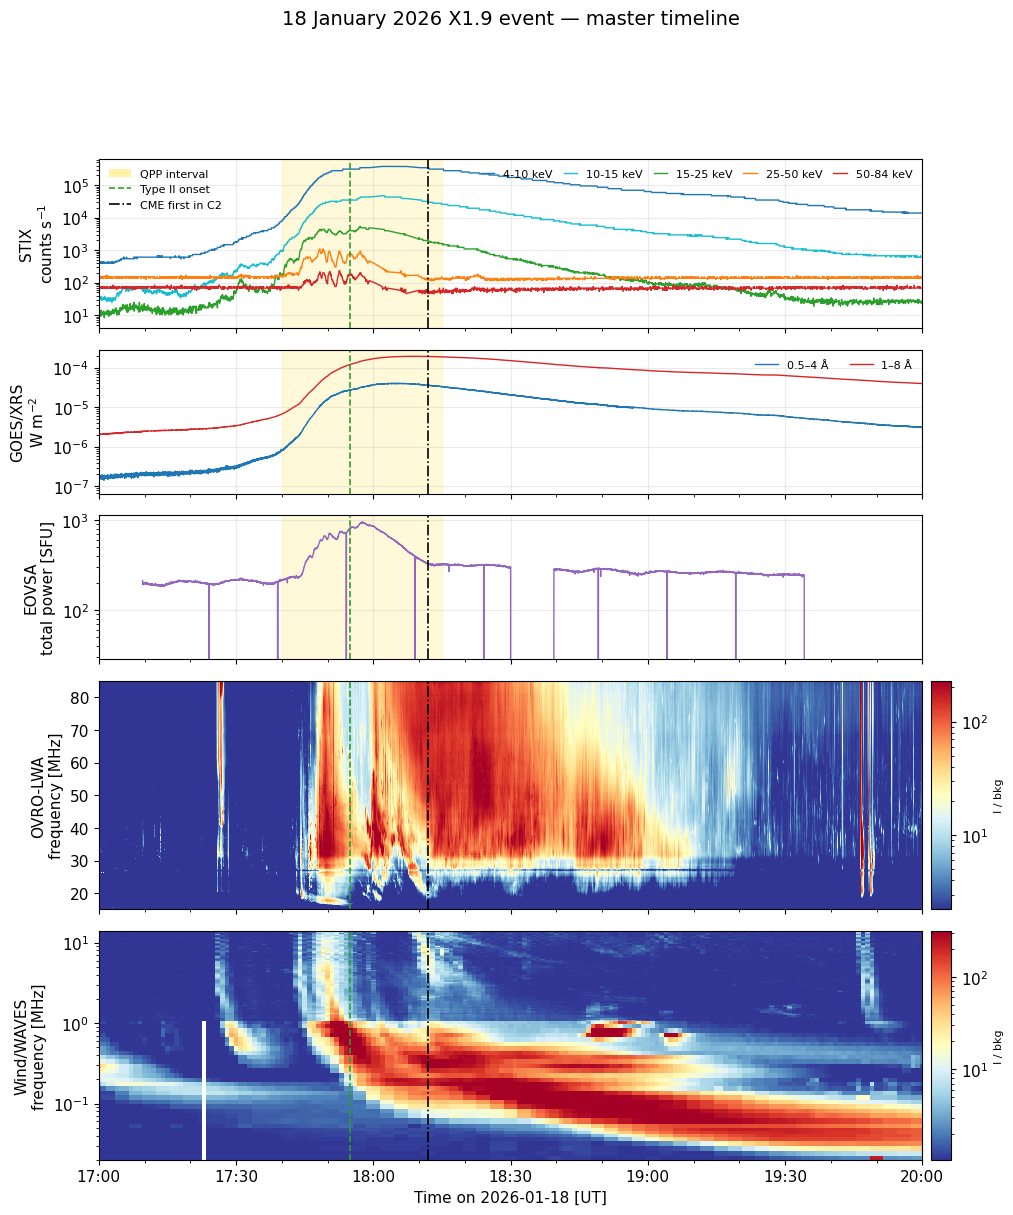

In [28]:
# ============================ the master timeline figure ============================
def spec_norm(data, lo=40, hi=99.5):
    v = data[np.isfinite(data)]
    return colors.LogNorm(vmin=max(np.nanpercentile(v, lo), 1e-3), vmax=np.nanpercentile(v, hi))


fig = plt.figure(figsize=[11, 13])
gs = GridSpec(5, 2, figure=fig, width_ratios=[40, 1],
              height_ratios=[1.0, 0.85, 0.85, 1.35, 1.35], hspace=0.12, wspace=0.02)
axes, caxes = [], []
for r in range(5):
    axes.append(fig.add_subplot(gs[r, 0], sharex=axes[0] if axes else None))
    caxes.append(fig.add_subplot(gs[r, 1]))
ax_stix, ax_goes, ax_eovsa, ax_lwa, ax_ip = axes

# 1) STIX
for band, col in zip(STIX_BANDS, STIX_COLORS):
    if band in stix:
        ax_stix.plot(stix[band]['t'], stix[band]['rate'], lw=1, color=col, label=band)
ax_stix.set_yscale('log')
ax_stix.set_ylabel('STIX\ncounts s$^{-1}$')
ax_stix.grid(alpha=0.25)
caxes[0].axis('off')

# 2) GOES/XRS
ax_goes.plot(gdf.index, gdf['xrsa'], lw=1, color='tab:blue', label='0.5–4 Å')
ax_goes.plot(gdf.index, gdf['xrsb'], lw=1, color='tab:red', label='1–8 Å')
ax_goes.set_yscale('log')
ax_goes.set_ylabel('GOES/XRS\nW m$^{-2}$')
ax_goes.grid(alpha=0.25)
ax_goes.legend(loc='upper right', ncol=2, fontsize=8, frameon=False)
caxes[1].axis('off')

# 3) EOVSA total power
if eov_tp is not None:
    ax_eovsa.plot(eov_tp.index, eov_tp.values, lw=1, color='tab:purple')
ax_eovsa.set_yscale('log')
ax_eovsa.set_ylabel('EOVSA\ntotal power [SFU]')
ax_eovsa.grid(alpha=0.25)
caxes[2].axis('off')

# 4) OVRO-LWA dynamic spectrum
if lwa_disp is not None:
    pm = ax_lwa.pcolormesh(lwa_t, lwa_f, lwa_disp, norm=spec_norm(lwa_disp),
                           cmap='RdYlBu_r', rasterized=True, shading='auto')
    fig.colorbar(pm, cax=caxes[3]).set_label('I / bkg', fontsize=8)
    ax_lwa.set_ylim(lwa_f.min(), lwa_f.max())
else:
    ax_lwa.text(0.5, 0.5, 'OVRO-LWA not loaded', transform=ax_lwa.transAxes,
                ha='center', va='center', color='0.6')
    caxes[3].axis('off')
ax_lwa.set_ylabel('OVRO-LWA\nfrequency [MHz]')

# 5) interplanetary dynamic spectrum
if ip_disp is not None:
    pm = ax_ip.pcolormesh(ip_t, ip_f, ip_disp, norm=spec_norm(ip_disp),
                          cmap='RdYlBu_r', rasterized=True, shading='auto')
    fig.colorbar(pm, cax=caxes[4]).set_label('I / bkg', fontsize=8)
    ax_ip.set_yscale('log')
    ax_ip.set_ylim(ip_f.min(), ip_f.max())
else:
    ax_ip.text(0.5, 0.5, f'{ip_label}: fetch pending\n(run the IP cell / check product names)',
               transform=ax_ip.transAxes, ha='center', va='center', color='0.6')
    caxes[4].axis('off')
ax_ip.set_ylabel(f'{ip_label}\nfrequency [MHz]')

# --- markers on every panel ---
for ax in axes:
    ax.axvspan(QPP_START, QPP_END, color='gold', alpha=0.15, zorder=0)
    ax.axvline(TYPEII_ONSET, color='tab:green', ls='--', lw=1.2)
    ax.axvline(CME_C2_FIRST, color='k', ls='-.', lw=1.2)

# legends on the top panel: energy bands (right) + markers (left)
band_leg = ax_stix.legend(loc='upper right', ncol=5, fontsize=8, frameon=False,
                          columnspacing=1.0, handlelength=1.2)
ax_stix.add_artist(band_leg)
marker_handles = [Patch(facecolor='gold', alpha=0.35, label='QPP interval'),
                  Line2D([], [], color='tab:green', ls='--', lw=1.2, label='Type II onset'),
                  Line2D([], [], color='k', ls='-.', lw=1.2, label='CME first in C2')]
ax_stix.legend(handles=marker_handles, loc='upper left', fontsize=8, frameon=False)

# --- shared x-axis ---
ax_ip.set_xlim(*T_AXIS)
ax_ip.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
ax_ip.xaxis.set_minor_locator(mdates.MinuteLocator(interval=10))
ax_ip.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax_ip.set_xlabel(f'Time on {EVENT_DATE} [UT]')
for ax in axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

fig.suptitle('18 January 2026 X1.9 event — master timeline', fontsize=14, y=0.995)
# savefig(fig, 'master_timeline')
plt.show()

### Notes

- **Data root** is auto-detected from `DATA_ROOT_CANDIDATES` — `/home/mnedal/data` on the DIAS
  machine. STIX/GOES fall back to a Fido download if the local file is missing, but EOVSA and
  OVRO-LWA are local-only, so an empty EOVSA/LWA panel means the path was not found (check the
  printed `DATA_ROOT`).
- **STIX** attenuator-in stretches (the soft-channel notches at the flare peak) are masked on the
  RCR state and bridged by interpolation, so the curve shows the trend, not the notches.
- **Interplanetary panel**: `IP_SOURCE='wind'` uses CDAWeb `WI_L2_WAV_RAD1/RAD2` (L1, no shift);
  `IP_SOURCE='rpw'` uses SOAR `RPW-HFR-SURV`(+`TNR`), shifted to Earth-arrival. Each receiver is
  read on its own frequency axis, background-divided, resampled onto a common `IP_BIN_S` (60 s)
  grid, then the receivers are stacked in frequency — no column-index mixing, no fine-grid stripes.
  The reader prints the epoch/frequency/intensity variables it picked; set `FLUX_OVERRIDE` if a
  product exposes an unexpected intensity variable.
- **Frame** — STIX and RPW are on Earth-arrival time; Wind/GOES/EOVSA/OVRO-LWA are already Earth/L1.